In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [2]:
df = pd.read_csv("marketing_and_sales_data_evaluate_lr.csv")

df.head()

,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


In [3]:
print(df.shape)

print(df.info())

print(df.isnull().sum())

(4572, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB
None
TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64


In [4]:
df = df.dropna()

In [5]:
print(df.isnull().sum())

TV              0
Radio           0
Social_Media    0
Sales           0
dtype: int64


                    TV     Radio  Social_Media     Sales
TV            1.000000  0.869158      0.527687  0.999497
Radio         0.869158  1.000000      0.606338  0.868638
Social_Media  0.527687  0.606338      1.000000  0.527446
Sales         0.999497  0.868638      0.527446  1.000000


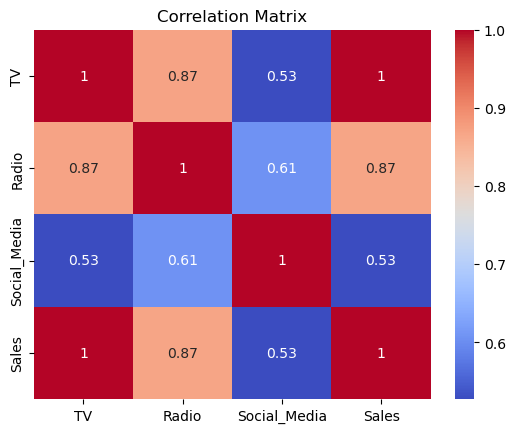

In [6]:
correlation_matrix = df.corr(numeric_only=True)

print(correlation_matrix)

sns.heatmap(correlation_matrix,
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

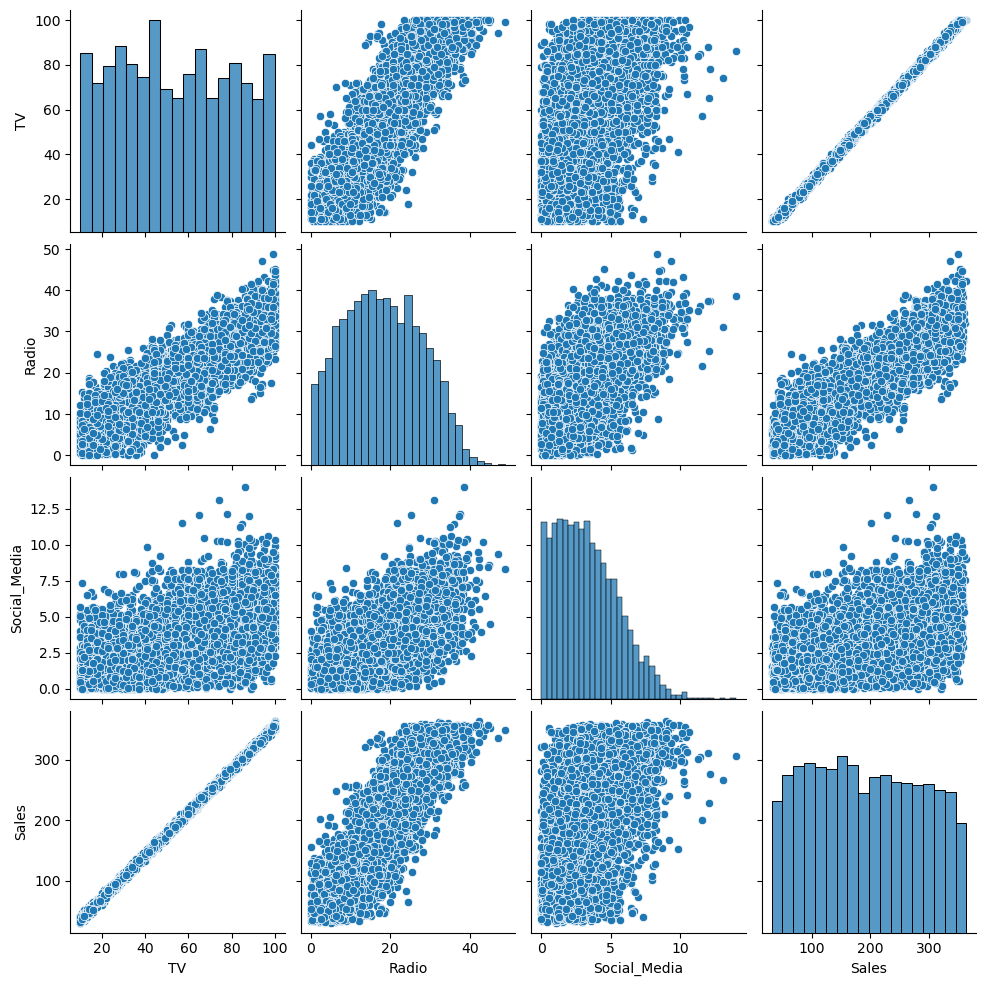

In [7]:
sns.pairplot(df)

plt.show()

In [8]:
X = df["TV"]

y = df["Sales"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Thu, 11 Jun 2026   Prob (F-statistic):               0.00
Time:                        07:17:31   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1325      0.101     -1.317      0.1

In [9]:
predictions = model.predict(X)

residuals = y - predictions

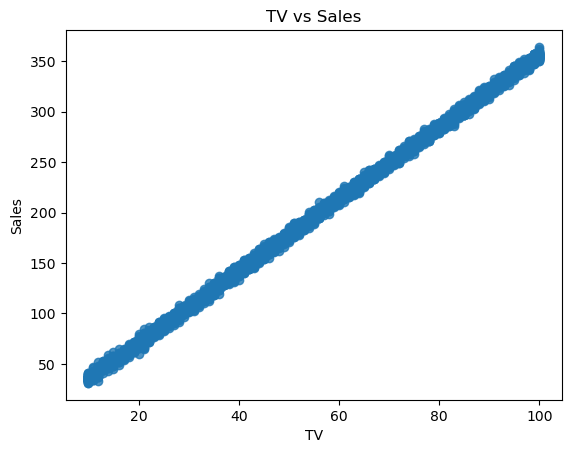

In [10]:
sns.regplot(
    x=df["TV"],
    y=df["Sales"]
)

plt.title("TV vs Sales")
plt.show()

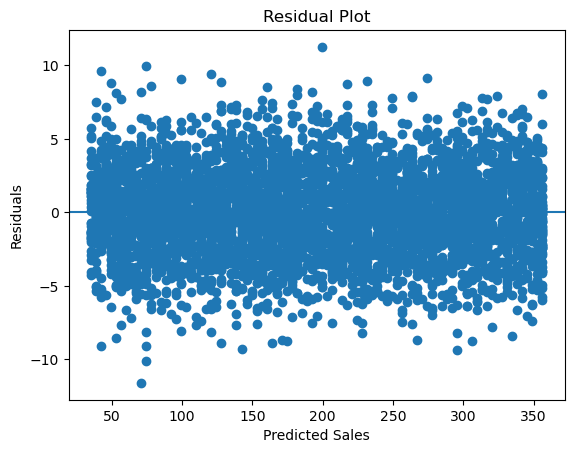

In [11]:
plt.scatter(predictions, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

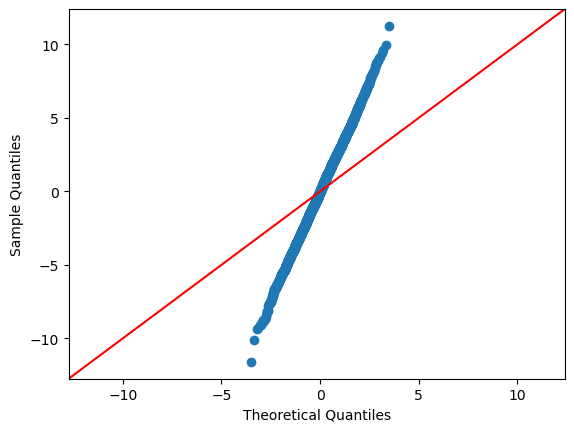

In [12]:
sm.qqplot(residuals, line="45")

plt.show()